# Train Photometry-Only CFM on DESI Data (FastSpecFit V2)

## Galaxy Properties (9D):
1. Z (Redshift) - linear
2. log(M*/M☉) (Log Stellar Mass) - log space (from LOGMSTAR)
3. log(SFR) (Log Star Formation Rate) - log space
4. DN4000 (4000Å break strength) - linear
5. AV (Dust attenuation) - linear
6. HBETA_FLUX - linear
7. OIII_5007_FLUX - linear
8. HALPHA_FLUX - linear
9. NII_6584_FLUX - linear

## Photometry Conditioning (5D):
5 magnitudes (G, R, Z, W1, W2) - normalized

## Cuts Applied:
- Z ∈ [0.02, 0.31]
- DN4000 ∈ [0, 5]
- All values finite

In [1]:
from cfm_models import ImprovedPhotometryConditionalFlowModelSimple
from cfm_utils import sample_properties_rk4, sample_properties_distribution_rk4

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from astropy.io import fits
import h5py
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import corner

from sklearn.model_selection import train_test_split

# Preprocessing (FastSpecFit V2 - 9 properties)

In [2]:
# Load the FastSpecFit FITS file
fits_path = Path("fastspec-iron.fits")

def to_native(arr):
    """Ensure a NumPy array is in native-endian dtype."""
    a = np.asarray(arr)
    if a.dtype.kind in "fiu":
        if a.dtype.byteorder == '>' or (a.dtype.byteorder == '=' and not np.little_endian):
            return a.byteswap().view(a.dtype.newbyteorder("="))
    return a

print("Loading FastSpecFit FITS file and applying preprocessing...")

Loading FastSpecFit FITS file and applying preprocessing...


In [3]:
# Load and filter FITS data
# Properties: Z, LOGMSTAR, SFR, DN4000, AV, HBETA_FLUX, OIII_5007_FLUX, HALPHA_FLUX, NII_6584_FLUX

print("\nLoading HDU[1] (FASTSPEC) properties...")
with fits.open(fits_path, memmap=True) as hdul:
    fastspec_data = hdul[1].data
    
    print("Loading columns: Z, LOGMSTAR, SFR, DN4000, AV, HBETA_FLUX, OIII_5007_FLUX, HALPHA_FLUX, NII_6584_FLUX")
    
    # Load HDU[1] data into DataFrame
    df_hdu1 = pd.DataFrame({
        'TARGETID': to_native(fastspec_data['TARGETID']),
        'Z': to_native(fastspec_data['Z']),
        'LOGMSTAR': to_native(fastspec_data['LOGMSTAR']),
        'SFR': to_native(fastspec_data['SFR']),
        'DN4000': to_native(fastspec_data['DN4000']),
        'AV': to_native(fastspec_data['AV']),
        'HBETA_FLUX': to_native(fastspec_data['HBETA_FLUX']),
        'OIII_5007_FLUX': to_native(fastspec_data['OIII_5007_FLUX']),
        'HALPHA_FLUX': to_native(fastspec_data['HALPHA_FLUX']),
        'NII_6584_FLUX': to_native(fastspec_data['NII_6584_FLUX'])
    })
    
    print(f"Loaded {len(df_hdu1)} galaxies from HDU[1]")

print("\nLoading HDU[2] (METADATA) photometry...")
with fits.open(fits_path, memmap=True) as hdul:
    metadata_data = hdul[2].data
    
    df_hdu2 = pd.DataFrame({
        'TARGETID': to_native(metadata_data['TARGETID']),
        'SPECTYPE': np.char.strip(metadata_data['SPECTYPE'].astype(str)),
        'ZWARN': to_native(metadata_data['ZWARN']),
        'FLUX_G': to_native(metadata_data['FLUX_G']),
        'FLUX_R': to_native(metadata_data['FLUX_R']),
        'FLUX_Z': to_native(metadata_data['FLUX_Z']),
        'FLUX_W1': to_native(metadata_data['FLUX_W1']),
        'FLUX_W2': to_native(metadata_data['FLUX_W2'])
    })
    
    print(f"Loaded {len(df_hdu2)} galaxies from HDU[2]")

# Check for duplicate TARGETIDs
print("\nChecking for duplicate TARGETIDs...")
n_dup_hdu1 = df_hdu1['TARGETID'].duplicated().sum()
n_dup_hdu2 = df_hdu2['TARGETID'].duplicated().sum()
print(f"  HDU[1] duplicates: {n_dup_hdu1}")
print(f"  HDU[2] duplicates: {n_dup_hdu2}")

if n_dup_hdu1 > 0:
    df_hdu1 = df_hdu1.drop_duplicates(subset='TARGETID', keep='first').reset_index(drop=True)
if n_dup_hdu2 > 0:
    df_hdu2 = df_hdu2.drop_duplicates(subset='TARGETID', keep='first').reset_index(drop=True)

# Merge
print("\nMerging HDU[1] and HDU[2] by TARGETID...")
df_merged = pd.merge(df_hdu1, df_hdu2, on='TARGETID', how='inner')
print(f"Common targets in both HDUs: {len(df_merged)}")

# Apply quality cuts - redshift + DN4000 range + finite values
print("\nApplying quality cuts...")

mask = (
    (df_merged['SPECTYPE'] == 'GALAXY') & 
    (df_merged['ZWARN'] == 0) &
    (df_merged['Z'] > 0.02) &
    (df_merged['Z'] < 0.31) &
    (df_merged['DN4000'] >= 0) &
    (df_merged['DN4000'] <= 5) &
    df_merged.notna().all(axis=1)
)

df = df_merged[mask].reset_index(drop=True)
df = df.sample(frac=1, random_state=32).reset_index(drop=True)

print(f"After all cuts: {df.shape[0]} galaxies")
print(f"Cut statistics:")
print(f"  Z in [0.02, 0.31]: {((df_merged['Z'] > 0.02) & (df_merged['Z'] < 0.31)).sum()}")
print(f"  DN4000 in [0, 5]: {((df_merged['DN4000'] >= 0) & (df_merged['DN4000'] <= 5)).sum()}")
print(f"  All cuts combined: {mask.sum()}")


Loading HDU[1] (FASTSPEC) properties...
Loading columns: Z, LOGMSTAR, SFR, DN4000, AV, HBETA_FLUX, OIII_5007_FLUX, HALPHA_FLUX, NII_6584_FLUX
Loaded 17995820 galaxies from HDU[1]

Loading HDU[2] (METADATA) photometry...
Loaded 17995820 galaxies from HDU[2]

Checking for duplicate TARGETIDs...
  HDU[1] duplicates: 633659
  HDU[2] duplicates: 633659

Merging HDU[1] and HDU[2] by TARGETID...
Common targets in both HDUs: 17362161

Applying quality cuts...
After all cuts: 5257378 galaxies
Cut statistics:
  Z in [0.02, 0.31]: 5622892
  DN4000 in [0, 5]: 17212869
  All cuts combined: 5257378


In [4]:
# Build properties (9 dimensions)
# Z (redshift), LOGMSTAR, log(SFR), DN4000, AV, log(1+HBETA_FLUX), log(1+OIII_5007_FLUX), log(1+HALPHA_FLUX), log(1+NII_6584_FLUX)
redshift = df['Z'].values
logM = df['LOGMSTAR'].values
logSFR = np.log10(df['SFR'].values)
dn4000 = df['DN4000'].values
Av = df['AV'].values
hbeta_flux = np.log10(1 + df['HBETA_FLUX'].values)
oiii_flux = np.log10(1 + df['OIII_5007_FLUX'].values)
halpha_flux = np.log10(1 + df['HALPHA_FLUX'].values)
nii_flux = np.log10(1 + df['NII_6584_FLUX'].values)

unnorm_props = np.column_stack([redshift, logM, logSFR, dn4000, Av, hbeta_flux, oiii_flux, halpha_flux, nii_flux])

# Check for non-finite values
if not np.isfinite(unnorm_props).all():
    n_bad = (~np.isfinite(unnorm_props)).sum()
    print(f"Warning: {n_bad} non-finite values in properties, filtering...")
    finite_mask2 = np.isfinite(unnorm_props).all(axis=1)
    df = df[finite_mask2].reset_index(drop=True)
    unnorm_props = unnorm_props[finite_mask2]
    redshift, logM, logSFR, dn4000, Av, hbeta_flux, oiii_flux, halpha_flux, nii_flux = unnorm_props.T

print(f"After property filtering: {df.shape[0]} galaxies")

/tmp/ipykernel_20644/3280113212.py:5: RuntimeWarning: divide by zero encountered in log10
  logSFR = np.log10(df['SFR'].values)


After property filtering: 3934572 galaxies


# Cross-reference with h5 file target IDs

In [5]:
# Open H5 file and cross-reference with FITS
h5_file = '../astroclip_desi.1.1.5.h5'
f = h5py.File(h5_file, 'r')

all_h5_targetids = []
for group_key in f.keys():
    all_h5_targetids.append(f[group_key]['targetids'][:])
all_h5_targetids = np.concatenate(all_h5_targetids)

print(f"Total galaxies in h5 file: {len(all_h5_targetids)}")
print(f"Unique galaxies in h5 file: {len(np.unique(all_h5_targetids))}")

# Cross-reference
fits_targetids = df['TARGETID'].values
h5_targetids_set = set(all_h5_targetids)
in_h5 = np.array([tid in h5_targetids_set for tid in fits_targetids])
df_final = df[in_h5].reset_index(drop=True)

print(f"\nGalaxies in both FITS and h5: {len(df_final)}")

# Build property arrays from df_final (9 dimensions)
redshift_final = df_final['Z'].values
logM_final = df_final['LOGMSTAR'].values
logSFR_final = np.log10(df_final['SFR'].values)
dn4000_final = df_final['DN4000'].values
Av_final = df_final['AV'].values
hbeta_flux_final = np.log10(1 + df_final['HBETA_FLUX'].values)
oiii_flux_final = np.log10(1 + df_final['OIII_5007_FLUX'].values)
halpha_flux_final = np.log10(1 + df_final['HALPHA_FLUX'].values)
nii_flux_final = np.log10(1 + df_final['NII_6584_FLUX'].values)

properties = np.column_stack([
    redshift_final, logM_final, logSFR_final, dn4000_final, Av_final,
    hbeta_flux_final, oiii_flux_final, halpha_flux_final, nii_flux_final
])

# Normalize properties
prop_mean = properties.mean(axis=0)
prop_std = properties.std(axis=0)
tab_dataset = (properties - prop_mean) / prop_std

print(f"\nProperties shape: {tab_dataset.shape}")
print(f"Property means: {prop_mean}")
print(f"Property stds: {prop_std}")
print(f"Property names: ['Z', 'log(M*)', 'log(SFR)', 'DN4000', 'AV', 'log(1+HBETA)', 'log(1+OIII)', 'log(1+HALPHA)', 'log(1+NII)']")

# Prepare photometry
print("\nPreparing photometry conditioning (5 bands: G, R, Z, W1, W2)...")
photometry_array = np.column_stack([
    df_final['FLUX_G'].values,
    df_final['FLUX_R'].values,
    df_final['FLUX_Z'].values,
    df_final['FLUX_W1'].values,
    df_final['FLUX_W2'].values
])

mags = 22.5 - 2.5 * np.log10(np.maximum(photometry_array, 1e-10))
mags_mean = mags.mean(axis=0)
mags_std = mags.std(axis=0)
phot_dataset = (mags - mags_mean) / mags_std

print(f"\nPhotometry shape: {phot_dataset.shape}")

f.close()

Total galaxies in h5 file: 197976
Unique galaxies in h5 file: 197976

Galaxies in both FITS and h5: 101291

Properties shape: (101291, 9)
Property means: [ 0.19164507 10.11076435 -0.64271024  1.4841489   0.37317761  0.93099276
  0.85916145  1.42817571  1.12591911]
Property stds: [0.07290728 0.66346609 0.69573988 0.33307407 0.50865346 0.51486937
 0.52108967 0.65086451 0.45660255]
Property names: ['Z', 'log(M*)', 'log(SFR)', 'DN4000', 'AV', 'log(1+HBETA)', 'log(1+OIII)', 'log(1+HALPHA)', 'log(1+NII)']

Preparing photometry conditioning (5 bands: G, R, Z, W1, W2)...

Photometry shape: (101291, 5)


In [6]:
# SPECTYPE counts after cross-matching with H5 file
print("SPECTYPE counts in final dataset (after H5 cross-match):")
print(df_final['SPECTYPE'].value_counts().to_string())
print(f"\nTotal: {len(df_final)}")

SPECTYPE counts in final dataset (after H5 cross-match):
GALAXY    101291

Total: 101291


In [7]:
# ZWARN counts after cross-matching with H5 file
print("ZWARN counts in final dataset (after H5 cross-match):")
print(df_final['ZWARN'].value_counts().to_string())
print(f"\nTotal: {len(df_final)}")

ZWARN counts in final dataset (after H5 cross-match):
0    101291

Total: 101291


/home/myunus/anaconda3/lib/python3.10/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


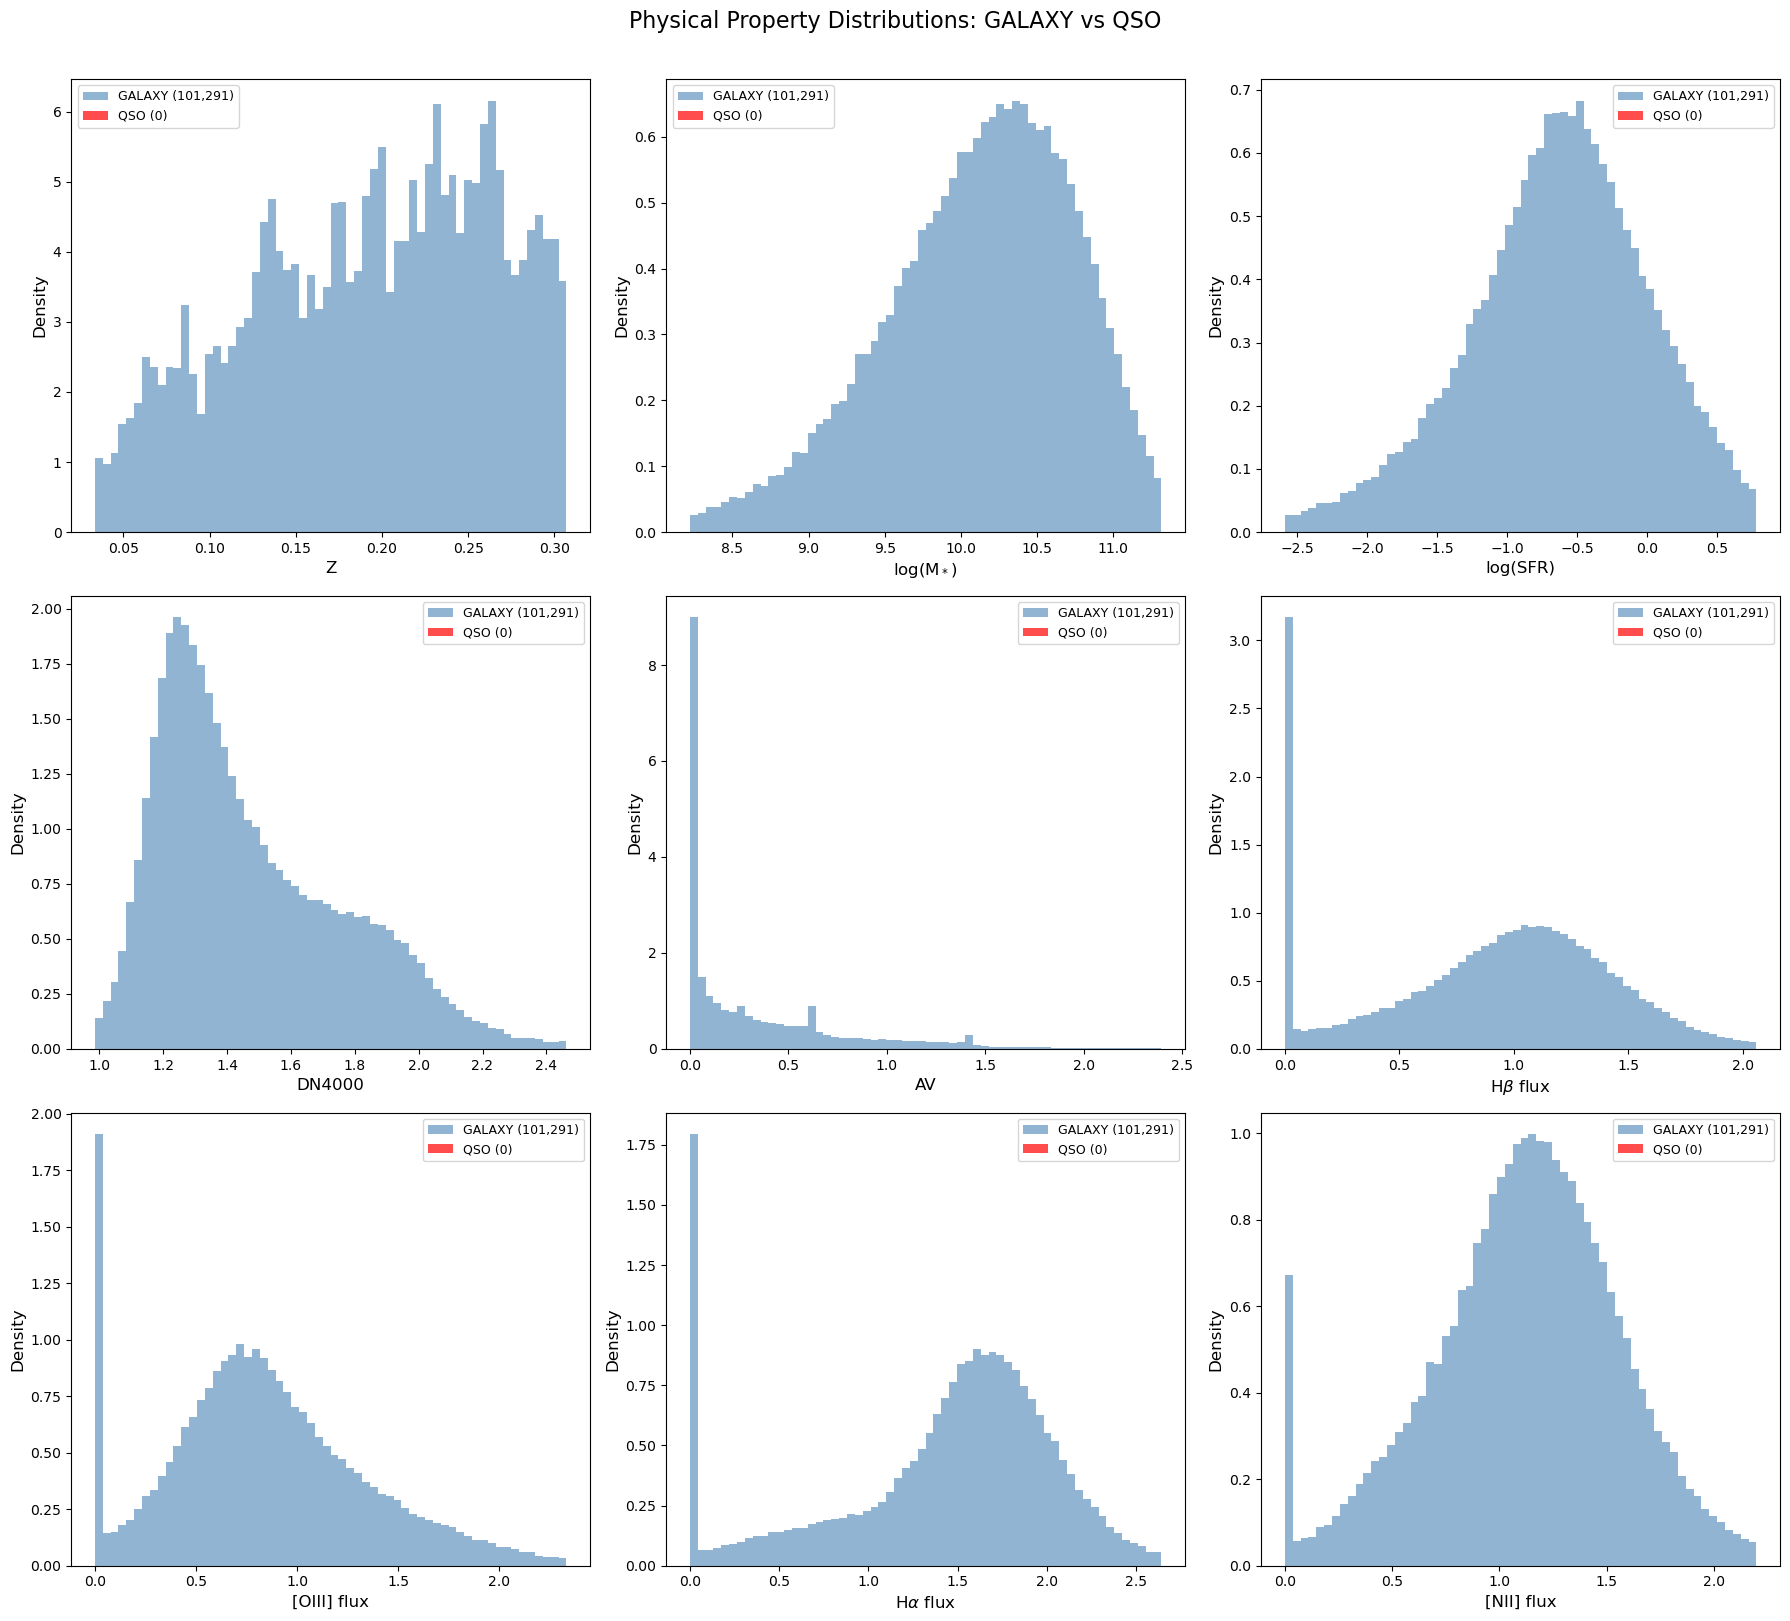

GALAXY: 101,291  |  QSO: 0  |  Total: 101,291


In [8]:
# Visualize physical properties color-coded by SPECTYPE (GALAXY vs QSO)
is_qso = (df_final['SPECTYPE'] == 'QSO').values
is_gal = ~is_qso

property_labels = ['Z', r'log(M$_*$)', 'log(SFR)', 'DN4000', 'AV',
                   r'H$\beta$ flux', r'[OIII] flux', r'H$\alpha$ flux', r'[NII] flux']

fig, axes = plt.subplots(3, 3, figsize=(18, 16))

for j, ax in enumerate(axes.flat):
    vals = properties[:, j]
    lo, hi = np.percentile(vals, [1, 99])
    
    ax.hist(vals[is_gal], bins=60, range=(lo, hi), alpha=0.6, color='steelblue',
            label=f'GALAXY ({is_gal.sum():,})', density=True)
    ax.hist(vals[is_qso], bins=60, range=(lo, hi), alpha=0.7, color='red',
            label=f'QSO ({is_qso.sum():,})', density=True)
    
    ax.set_xlabel(property_labels[j], fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle('Physical Property Distributions: GALAXY vs QSO', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

print(f"GALAXY: {is_gal.sum():,}  |  QSO: {is_qso.sum():,}  |  Total: {len(df_final):,}")

# Dataset and Train/Val/Test Split

In [9]:
class PhotometryDataset(Dataset):
    def __init__(self, photometry, properties, indices):
        self.photometry = photometry
        self.properties = properties
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        phot = torch.from_numpy(self.photometry[actual_idx]).float()
        prop = torch.from_numpy(self.properties[actual_idx]).float()
        return phot, prop

# Create train/val/test splits
num_samples = len(phot_dataset)
indices = np.arange(num_samples)

train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=32)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=32)

print(f"Dataset split:")
print(f"  Training:   {len(train_idx):6d} samples")
print(f"  Validation: {len(val_idx):6d} samples")
print(f"  Test:       {len(test_idx):6d} samples")

train_dataset = PhotometryDataset(phot_dataset, tab_dataset, train_idx)
val_dataset = PhotometryDataset(phot_dataset, tab_dataset, val_idx)
test_dataset = PhotometryDataset(phot_dataset, tab_dataset, test_idx)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

Dataset split:
  Training:    81032 samples
  Validation:  10129 samples
  Test:        10130 samples


Generating corner plot of galaxy properties...


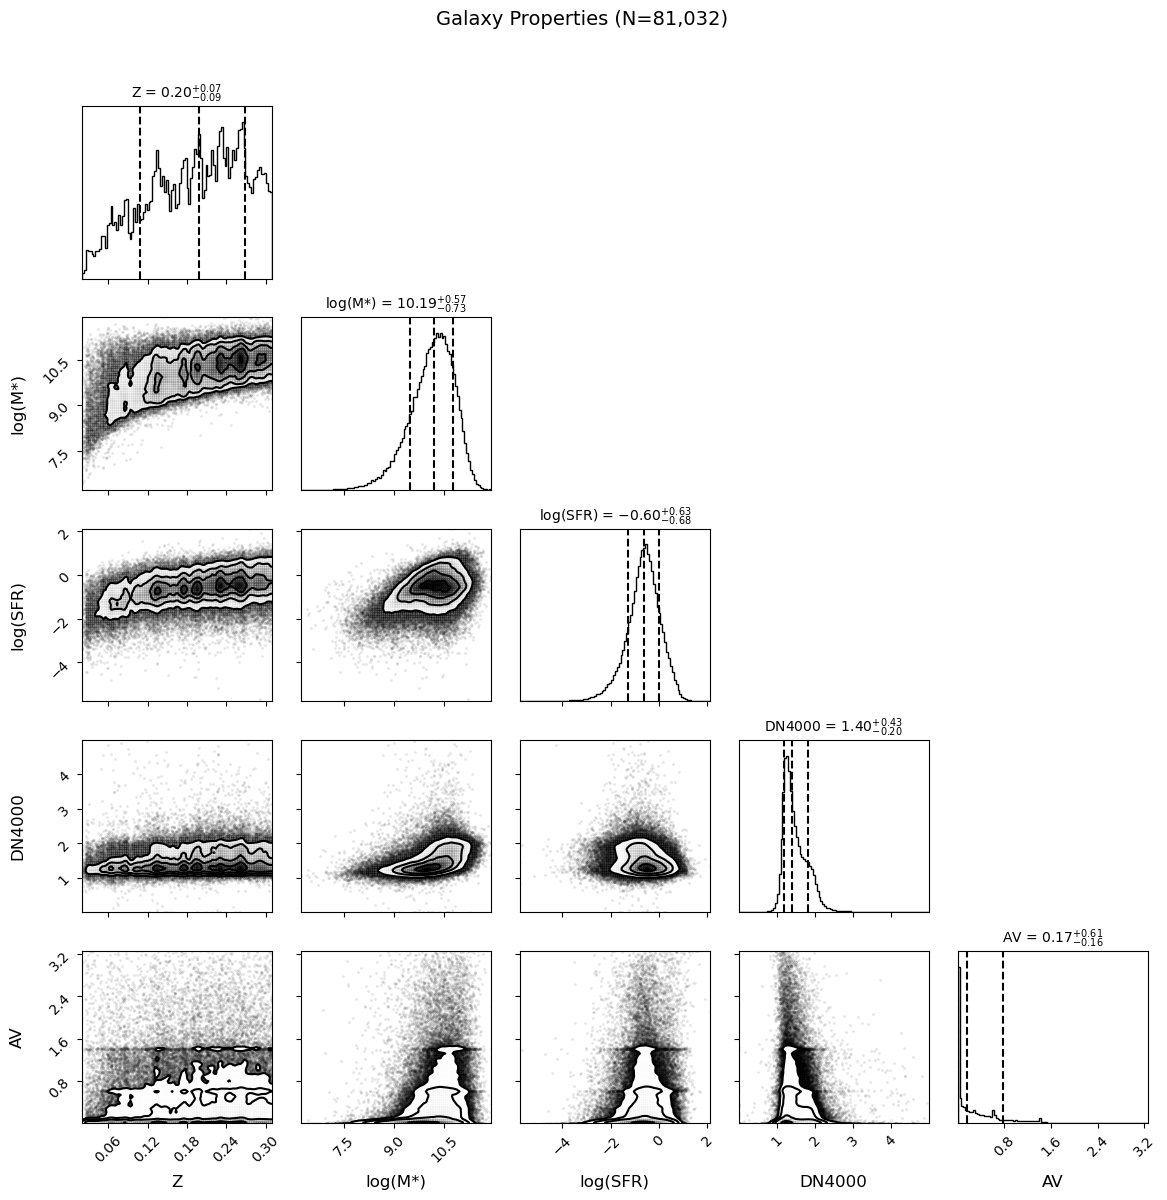


Generating corner plot of emission line fluxes [log(1+flux)]...


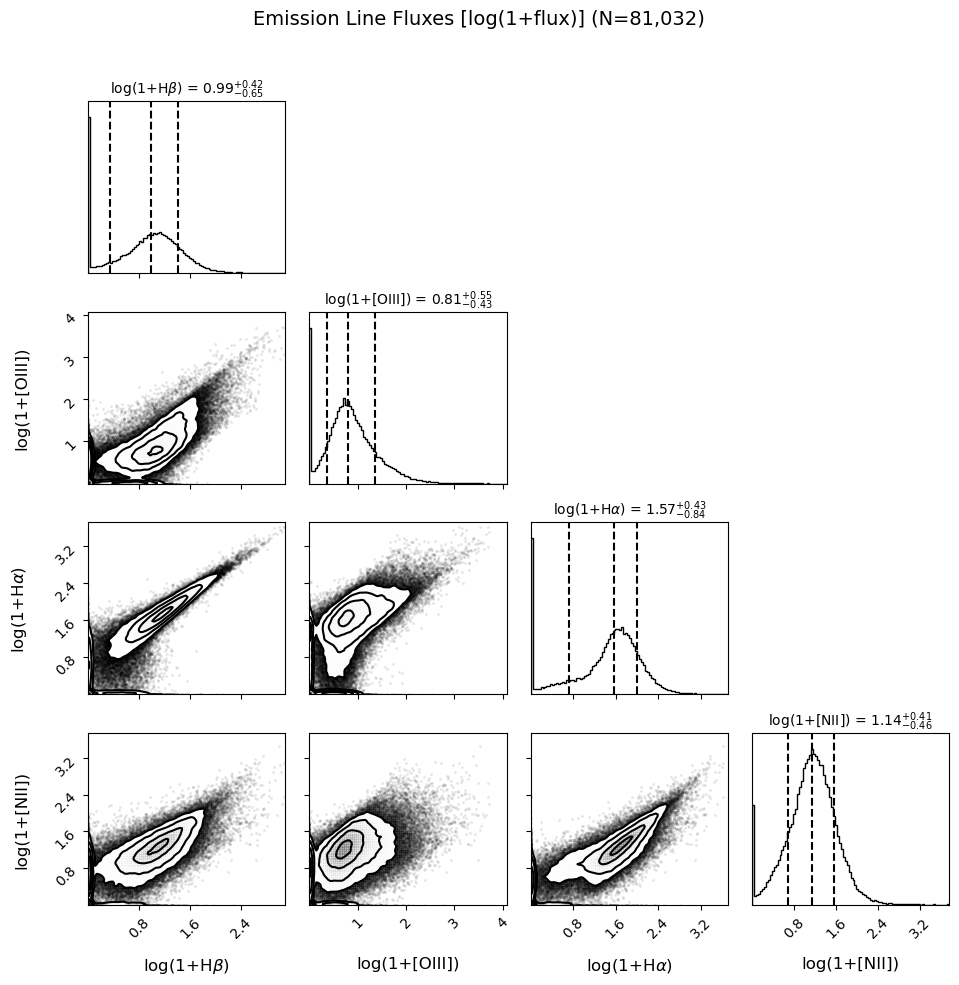

In [10]:
# Corner plots of training data (unnormalized properties)
train_properties = properties[train_idx]

# Corner plot 1: Galaxy properties (Z, log(M*), log(SFR), DN4000, AV)
print("Generating corner plot of galaxy properties...")

galaxy_props = train_properties[:, :5]  # First 5 columns
galaxy_labels = ['Z', 'log(M*)', 'log(SFR)', 'DN4000', 'AV']

fig1 = corner.corner(
    galaxy_props,
    labels=galaxy_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 12},
    smooth=1.0,
    bins=100
)

fig1.suptitle(f'Galaxy Properties (N={len(train_idx):,})', 
              fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

# Corner plot 2: Emission line fluxes displayed in log(1+flux) space
print("\nGenerating corner plot of emission line fluxes [log(1+flux)]...")

flux_props_raw = train_properties[:, 5:]  # Last 4 columns (raw fluxes)
# flux_props_log = np.log10(1 + flux_props_raw)
flux_props_log = flux_props_raw    # already in log scale
flux_labels = [r'log(1+H$\beta$)', r'log(1+[OIII])', r'log(1+H$\alpha$)', r'log(1+[NII])']

fig2 = corner.corner(
    flux_props_log,
    labels=flux_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 12},
    smooth=1.0,
    bins=100
)

fig2.suptitle(f'Emission Line Fluxes [log(1+flux)] (N={len(train_idx):,})', 
              fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

# Training Setup

In [11]:
# Training hyperparameters
save_model = True
num_epochs = 300
patience = 30
best_val_loss = float('inf')
patience_counter = 0
sigma = 1e-4

num_vars = tab_dataset.shape[1]  # 9 properties
phot_dim = phot_dataset.shape[1]  # 5 bands

print(f"Model configuration:")
print(f"  Property dimension: {num_vars}")
print(f"  Photometry dimension: {phot_dim}")
print(f"  Properties: Z, log(M*), log(SFR), DN4000, AV, log(1+HBETA), log(1+OIII), log(1+HALPHA), log(1+NII)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

num_gpus =  max(1, torch.cuda.device_count())
print(f"Number of GPUs: {num_gpus}")

base_model = ImprovedPhotometryConditionalFlowModelSimple(
    phot_dim=phot_dim, property_dim=num_vars
).to(device)

if num_gpus > 1:
    model = torch.nn.DataParallel(base_model)
else:
    model = base_model

lr = 1e-5 * num_gpus  # Scaled learning rate: linear scaling rule
optimizer = optim.AdamW(model.parameters(), lr=lr)
mse_loss = nn.MSELoss()

train_losses = []
val_losses = []

def train_epoch(loader, model, optimizer, device):
    model.train()
    total = 0.0
    for phot, prop in tqdm(loader, desc="Training", leave=False):
        bsz = phot.size(0)
        phot, prop = phot.to(device), prop.to(device)
        x0 = torch.randn(bsz, num_vars, device=device)
        t = torch.rand(bsz, 1, device=device)
        mu = (1-t)*x0 + t*prop
        x = mu + sigma*torch.randn_like(mu)
        target = prop - x0
        pred = model(t, x, phot)
        loss = mse_loss(pred, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item() * bsz
    return total / len(loader.dataset)

def validate_epoch(loader, model, device):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for phot, prop in tqdm(loader, desc="Validation", leave=False):
            bsz = phot.size(0)
            phot, prop = phot.to(device), prop.to(device)
            x0 = torch.randn(bsz, num_vars, device=device)
            t = torch.rand(bsz, 1, device=device)
            mu = (1-t)*x0 + t*prop
            x = mu + sigma*torch.randn_like(mu)
            target = prop - x0
            pred = model(t, x, phot)
            loss = mse_loss(pred, target)
            total += loss.item() * bsz
    return total / len(loader.dataset)

Model configuration:
  Property dimension: 9
  Photometry dimension: 5
  Properties: Z, log(M*), log(SFR), DN4000, AV, log(1+HBETA), log(1+OIII), log(1+HALPHA), log(1+NII)

Using device: cuda
Number of GPUs: 4


In [12]:
# Training loop
print("="*80)
print("STARTING TRAINING")
print("="*80)

for epoch in range(num_epochs):
    train_loss = train_epoch(train_loader, model, optimizer, device)
    val_loss = validate_epoch(val_loader, model, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        if hasattr(model, 'module'):
            best_model_state = model.module.state_dict()
        else:
            best_model_state = model.state_dict()
        patience_counter = 0
        print("  -> Validation loss improved; saving model.")
    else:
        patience_counter += 1
        print(f"  -> No improvement for {patience_counter} epoch(s).")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs!")
        break

if hasattr(model, 'module'):
    model.module.load_state_dict(best_model_state)
else:
    model.load_state_dict(best_model_state)

print("="*80)
print(f"TRAINING COMPLETE - Best val loss: {best_val_loss:.4f}")
print("="*80)

STARTING TRAINING


Epoch 1/300: Train Loss = 1.5234, Val Loss = 1.2450
  -> Validation loss improved; saving model.


Epoch 2/300: Train Loss = 1.1701, Val Loss = 1.1064
  -> Validation loss improved; saving model.


Epoch 3/300: Train Loss = 1.0644, Val Loss = 1.0421
  -> Validation loss improved; saving model.


Epoch 4/300: Train Loss = 1.0254, Val Loss = 1.0064
  -> Validation loss improved; saving model.


...

Epoch 207/300: Train Loss = 0.7329, Val Loss = 0.7315
  -> No improvement for 26 epoch(s).


Epoch 208/300: Train Loss = 0.7327, Val Loss = 0.7329
  -> No improvement for 27 epoch(s).


Epoch 209/300: Train Loss = 0.7317, Val Loss = 0.7410
  -> No improvement for 28 epoch(s).


Epoch 210/300: Train Loss = 0.7327, Val Loss = 0.7366
  -> No improvement for 29 epoch(s).


Epoch 211/300: Train Loss = 0.7319, Val Loss = 0.7409
  -> No improvement for 30 epoch(s).

Early stopping triggered after 211 epochs!
TRAINING COMPLETE - Best val loss: 0.7270


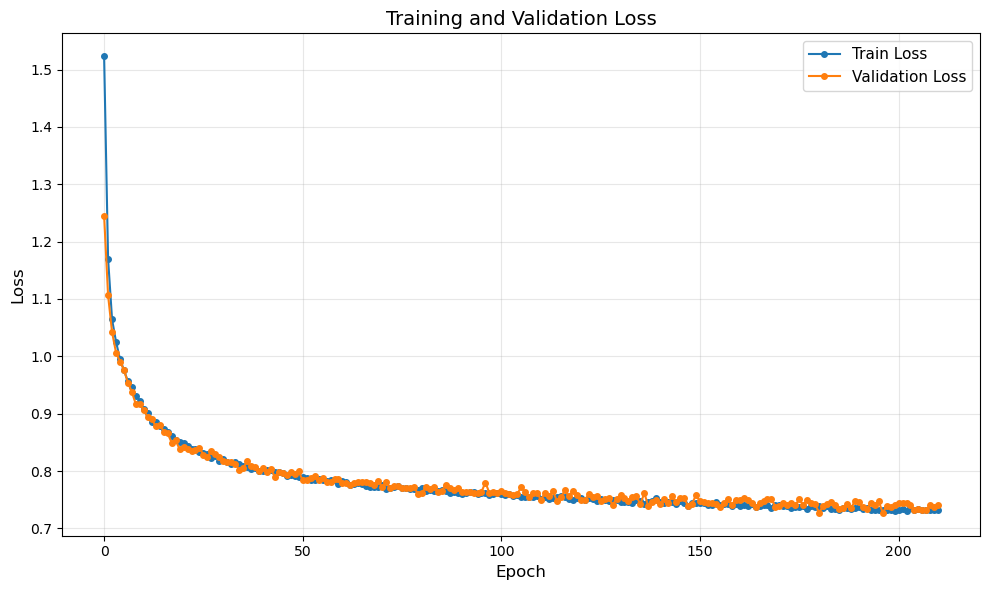

In [13]:
# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', marker='o', markersize=4)
plt.plot(val_losses, label='Validation Loss', marker='o', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Save model
if save_model:
    os.makedirs("models", exist_ok=True)
    model_path = f"models/best_photometry_model_FSFV2_9props_sigma1eneg4.pth"
    torch.save(best_model_state, model_path)
    print(f"Saved best model to {model_path}")

Saved best model to models/best_photometry_model_FSFV2_9props_sigma1eneg4.pth


## Test Set Evaluation

In [15]:
# Test evaluation
print("="*80)
print("EVALUATING ON TEST SET")
print("="*80)

def test_epoch(loader, model, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for phot, prop in tqdm(loader, desc="Testing"):
            bsz = phot.size(0)
            phot, prop = phot.to(device), prop.to(device)
            x0 = torch.randn(bsz, num_vars, device=device)
            t = torch.rand(bsz, 1, device=device)
            mu = (1-t)*x0 + t*prop
            x = mu + sigma*torch.randn_like(mu)
            target = prop - x0
            pred = model(t, x, phot)
            loss = mse_loss(pred, target)
            total_loss += loss.item() * bsz
    return total_loss / len(loader.dataset)

test_loss = test_epoch(test_loader, model, device)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Difference: {test_loss - best_val_loss:.4f}")

EVALUATING ON TEST SET


Testing: 100%|██████████| 40/40 [00:00<00:00, 119.20it/s]


Test Loss: 0.7303
Best Validation Loss: 0.7270
Difference: 0.0033
